# Photometry with Fink Data Transfer

This notebook shows how to access photometry using the Fink Data Transfer (https://lsst.fink-portal.org/download), and display a lightcurve. For the definition of fields, we refer the reader to:

- Documentation: https://doc.lsst.fink-broker.org/data/photometry/
- Schema page: https://lsst.fink-portal.org/schemas/

In [1]:
import requests
import pandas as pd
import numpy as np
import io
import seaborns
seaborn.set_context("poster")

import matplotlib.pyplot as plt

from fink_client.visualisation import extract_field

In [2]:
UNIQUE_BANDS = ["u", "g", "r", "i", "z", "y"]
MARKERS = {
    "u": "o",
    "g": "<",
    "r": ">",
    "i": "s",
    "z": "*",
    "y": "p",
}

COLORS = {
    "u": "#15284f", 
    "g": "#626d84", 
    "r": "#afb2b9", 
    "i": "#dbbeb2", 
    "z": "#e89070", 
    "y": "#f5622e"
}

In [3]:
def plot_lightcurve_allbands(time, flux, fluxErr, bands, ax, label=""):
    """Wrapper to plot all filter bands"""
    for band in UNIQUE_BANDS:
        mask = bands == band
        if mask.sum() == 0:
            continue
        ax.errorbar(
            time[mask],
            flux[mask],
            fluxErr[mask],
            color=COLORS[band],
            marker=MARKERS[band],
            label=f"{band} band",
            ls=""
        )

## Photometry

Let's download data for an object (use the provided yml configuration file on the [Data Transfer](https://lsst.fink-portal.org/download) service), and display its lightcurve based on the flux estimated from PSF photometry on the difference image:

In [4]:
# let's open 1 file
pdf = pd.read_parquet("ftransfer_lsst_2026-03-18_803281/part-0-0-117952.parquet")

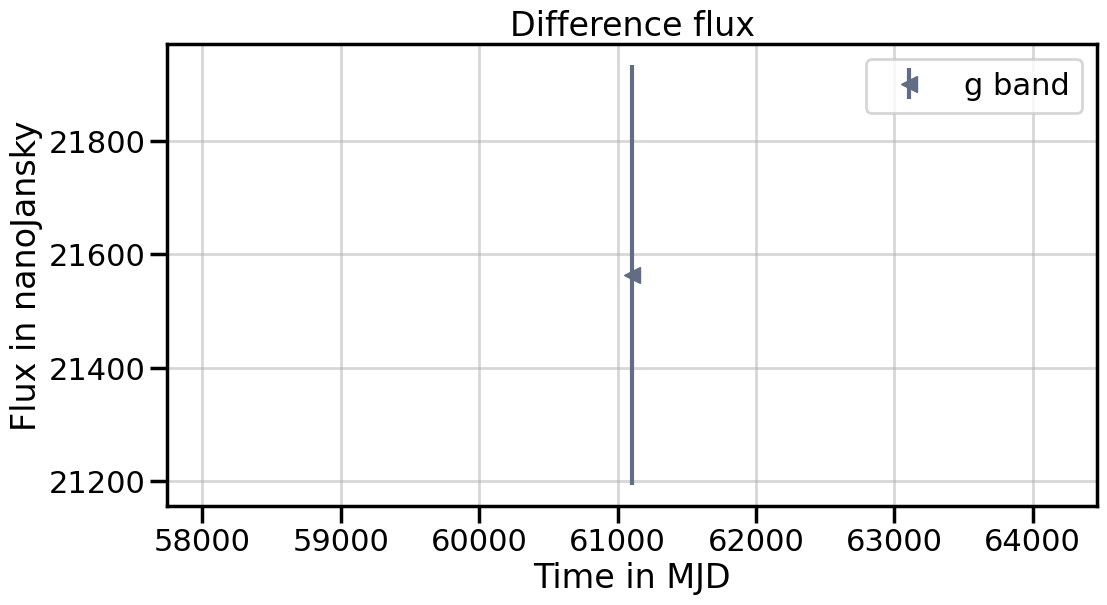

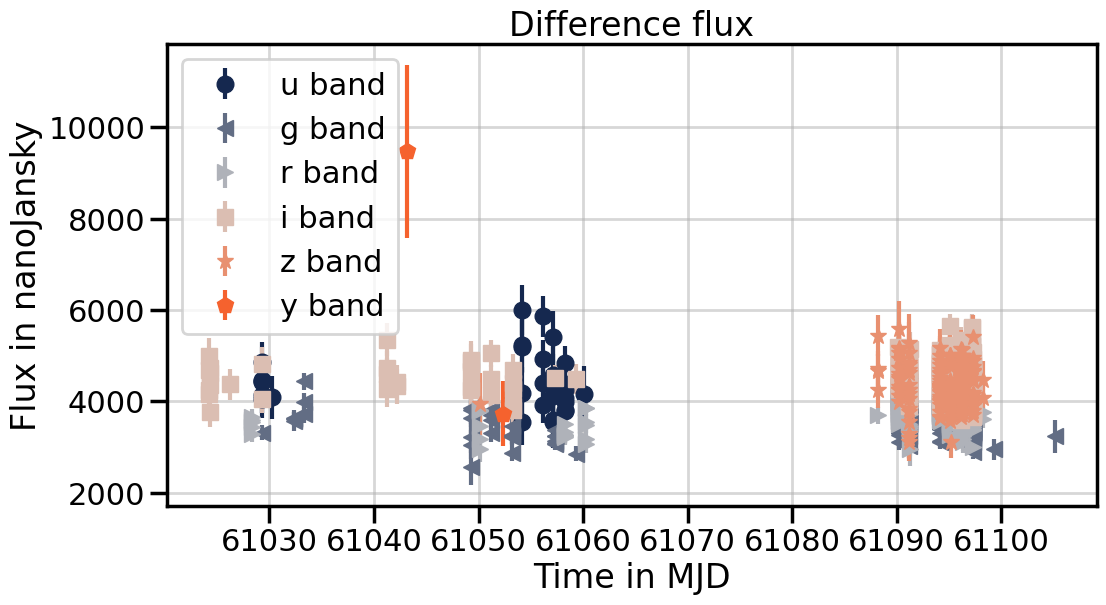

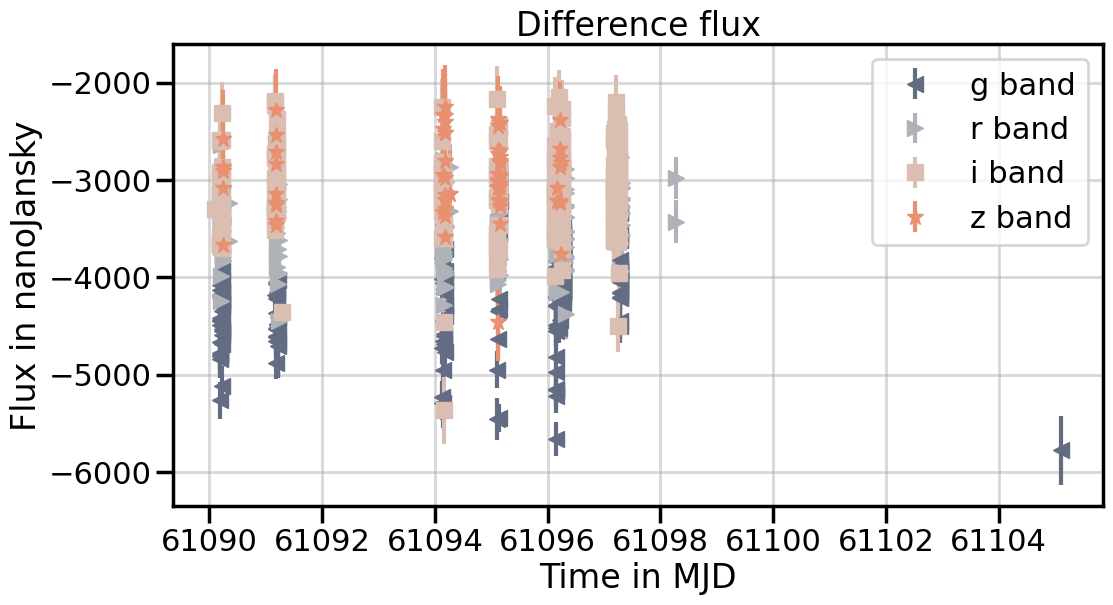

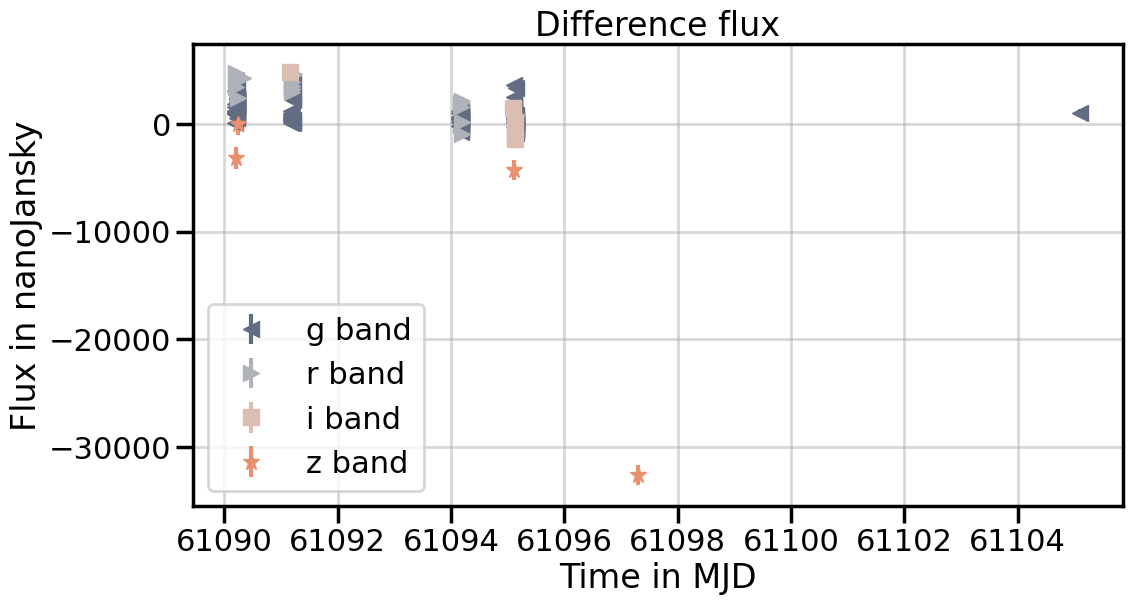

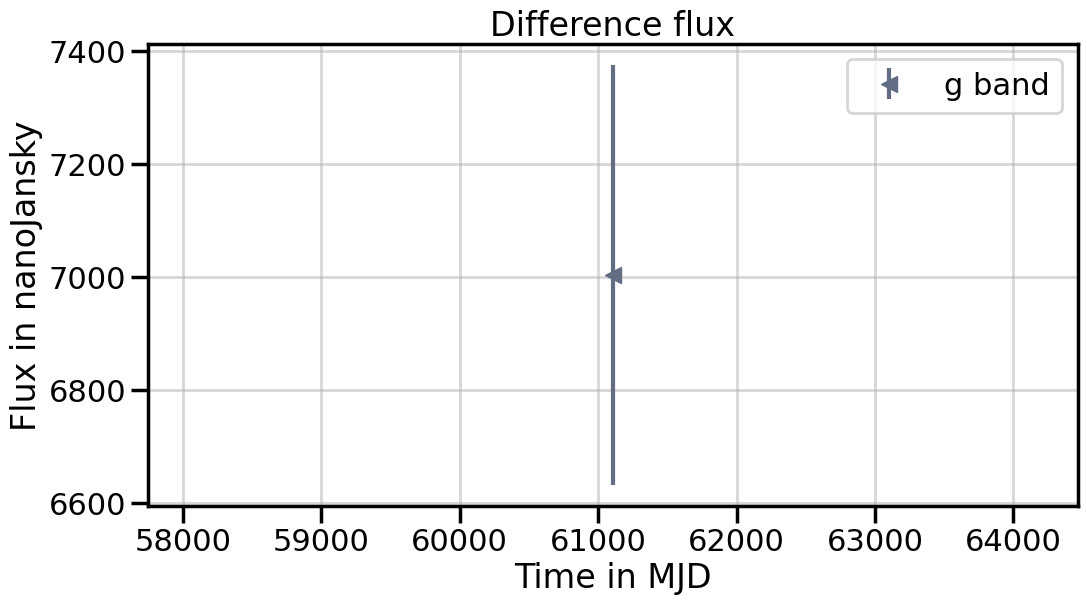

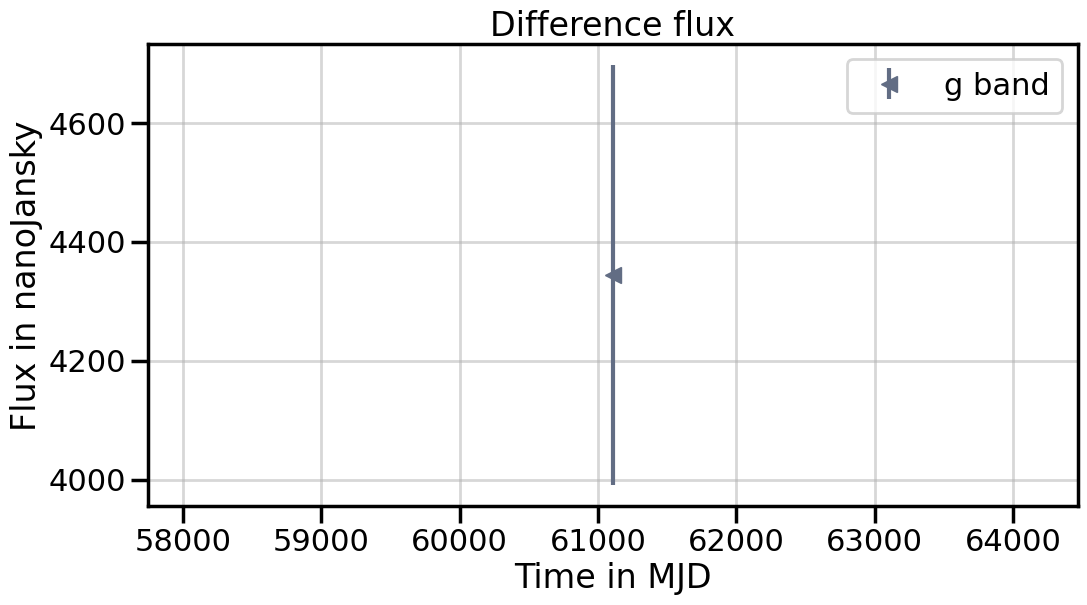

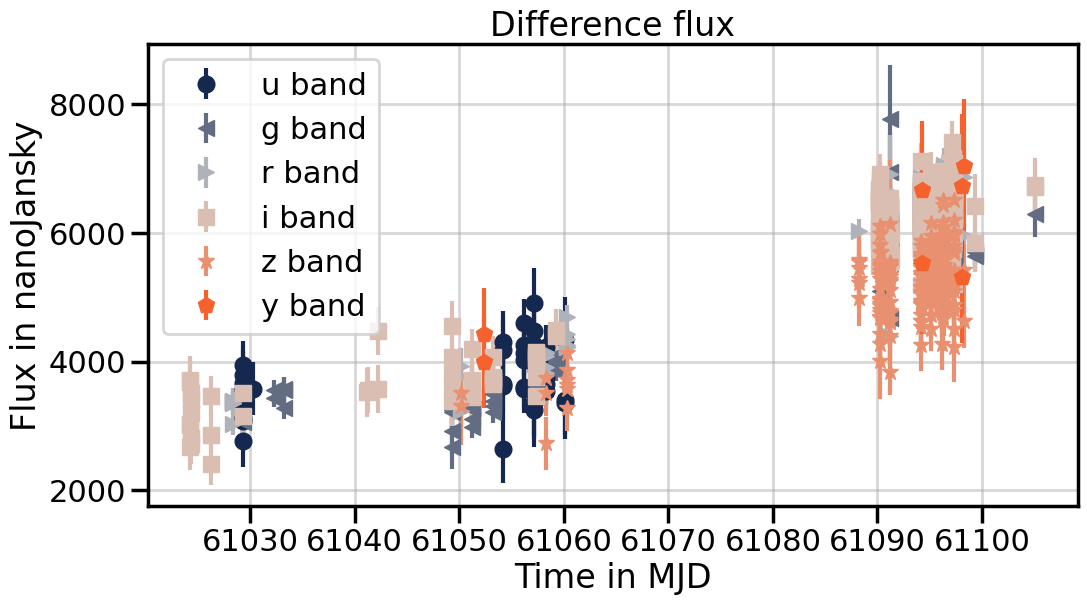

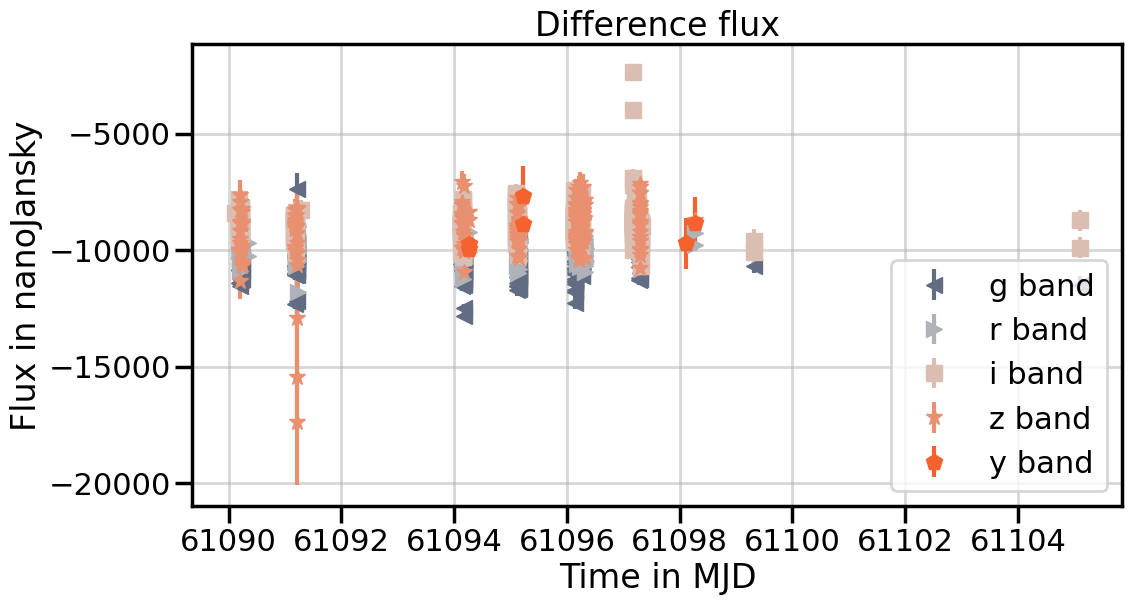

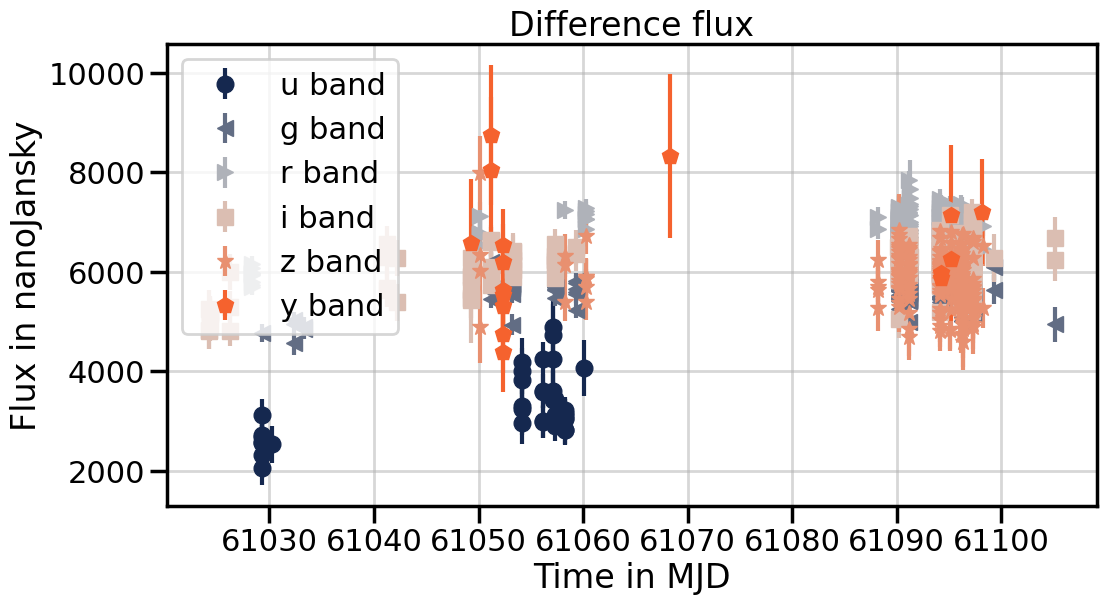

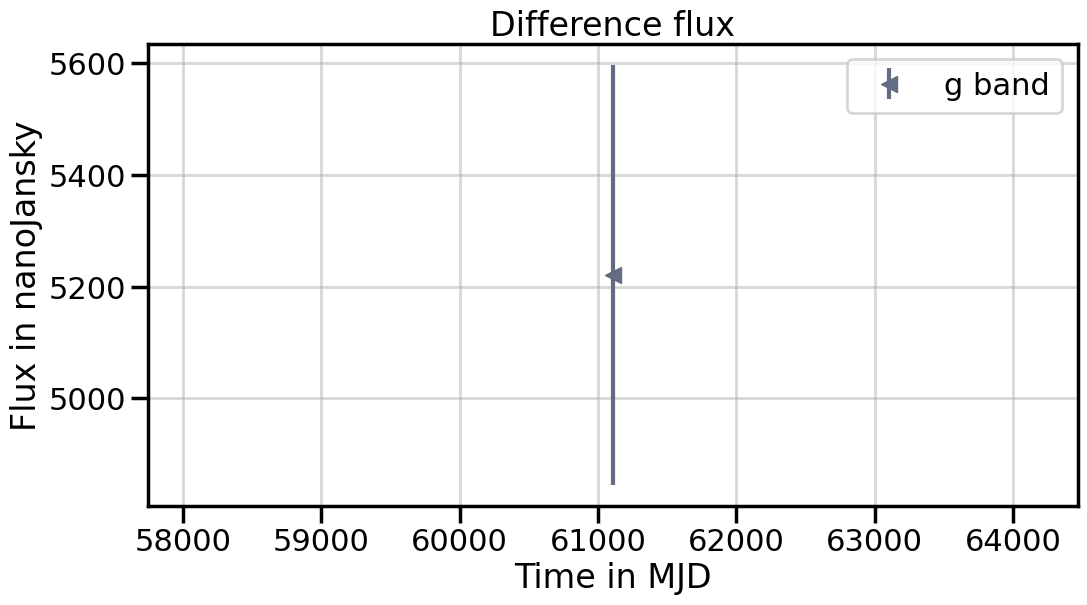

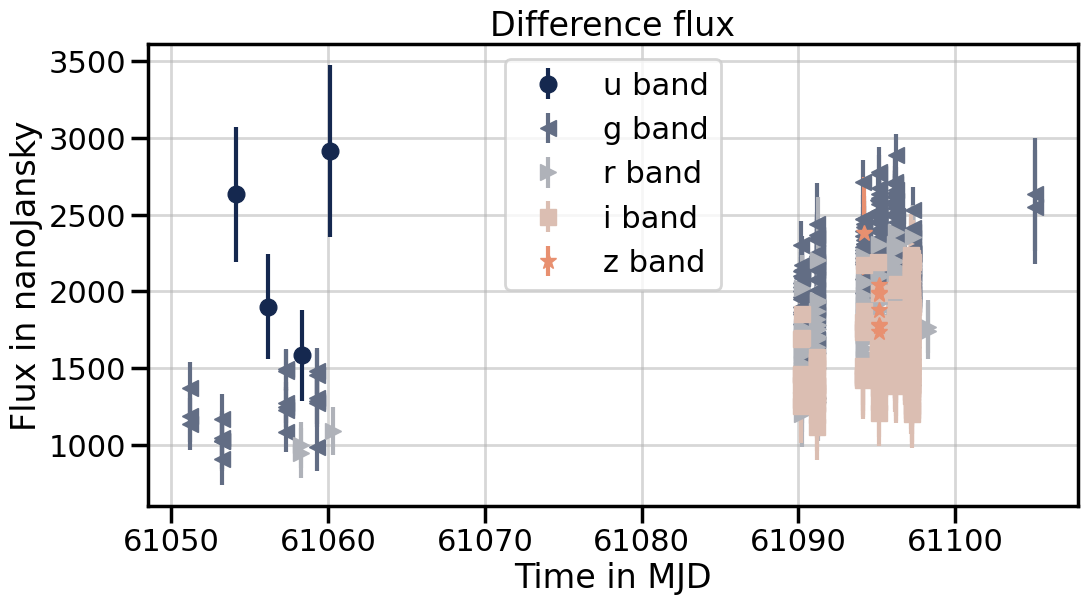

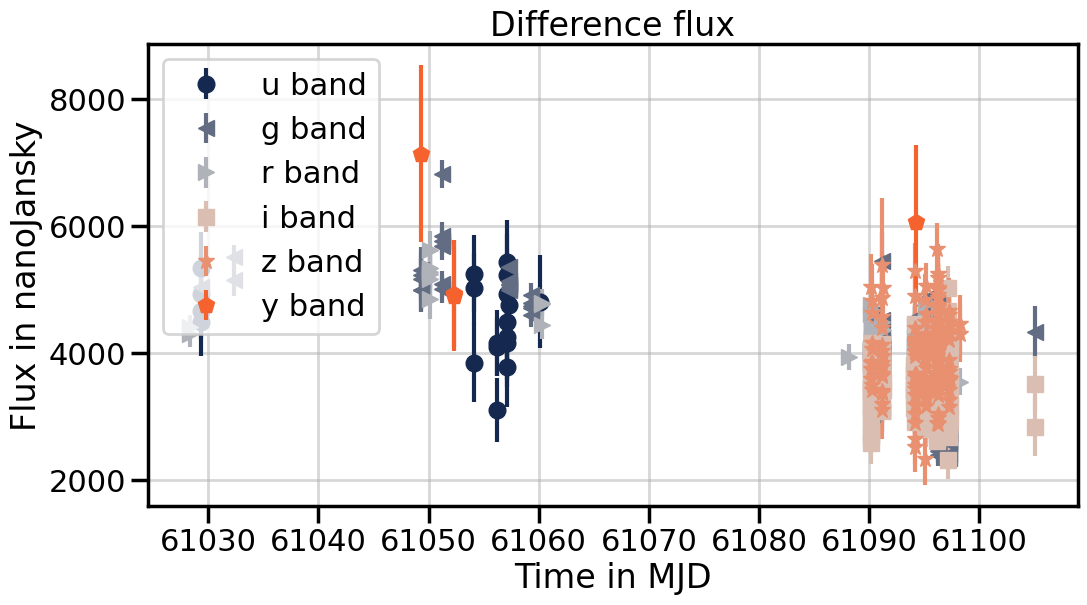

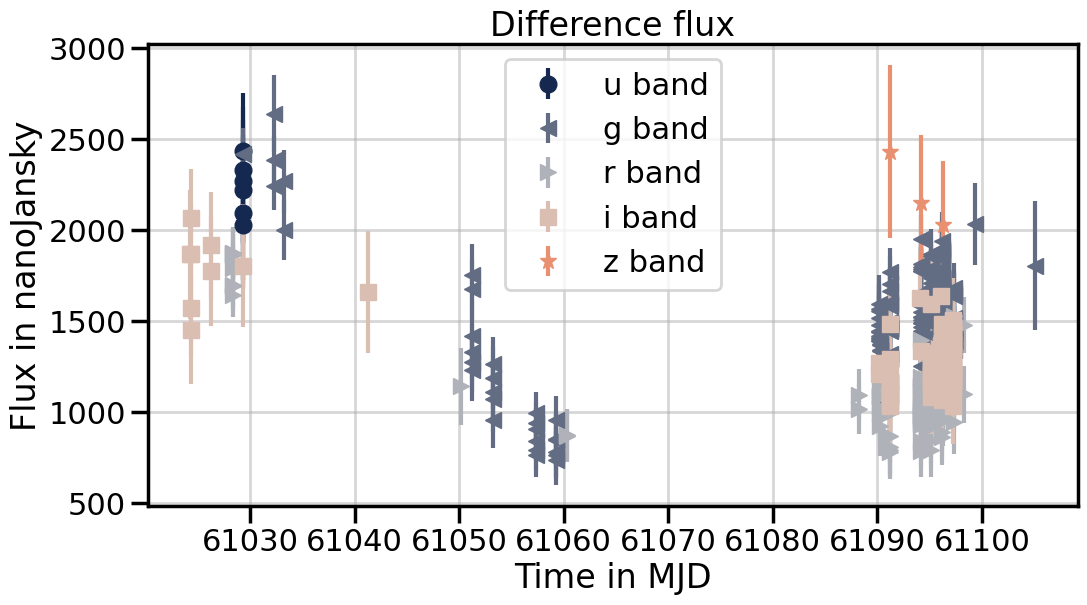

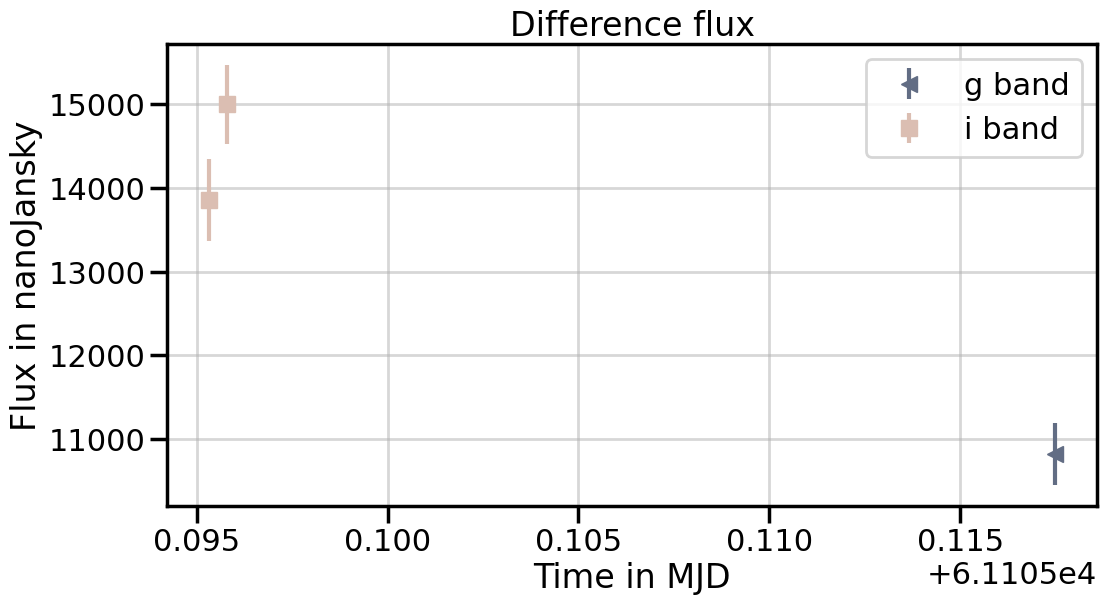

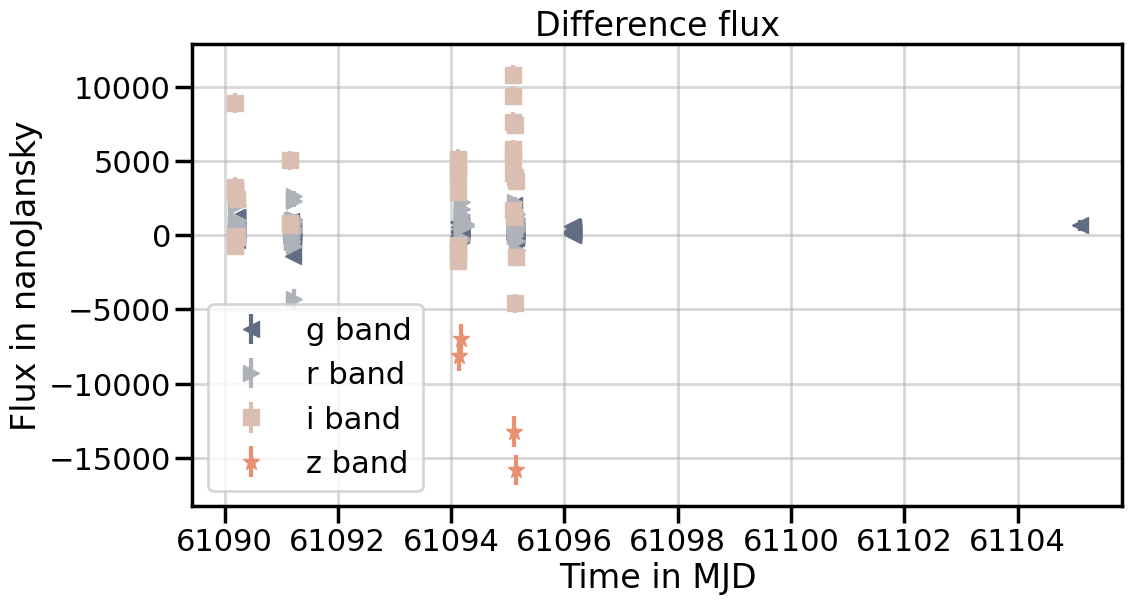

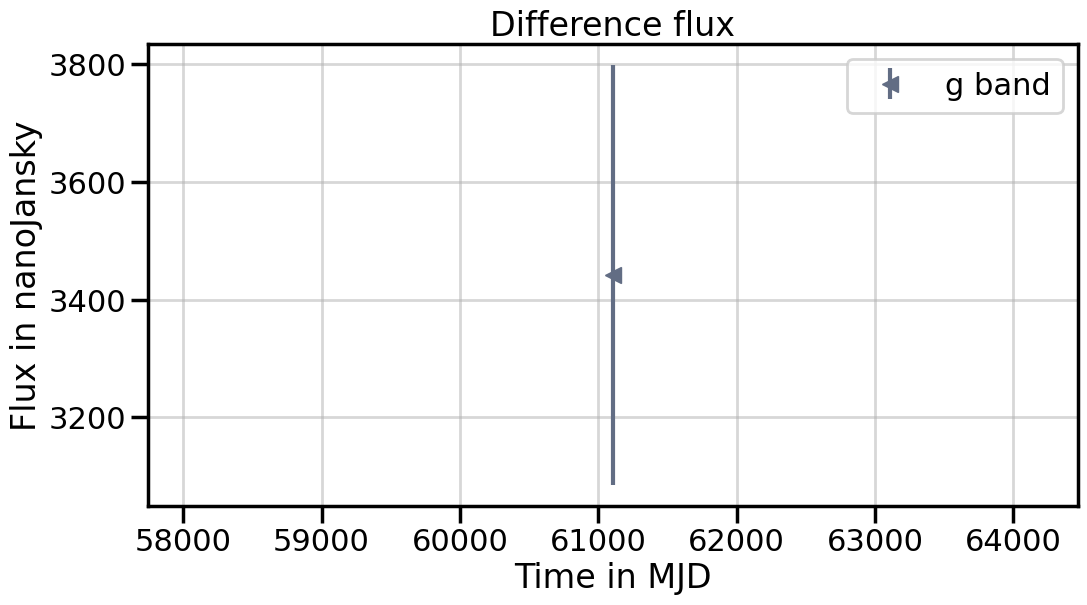

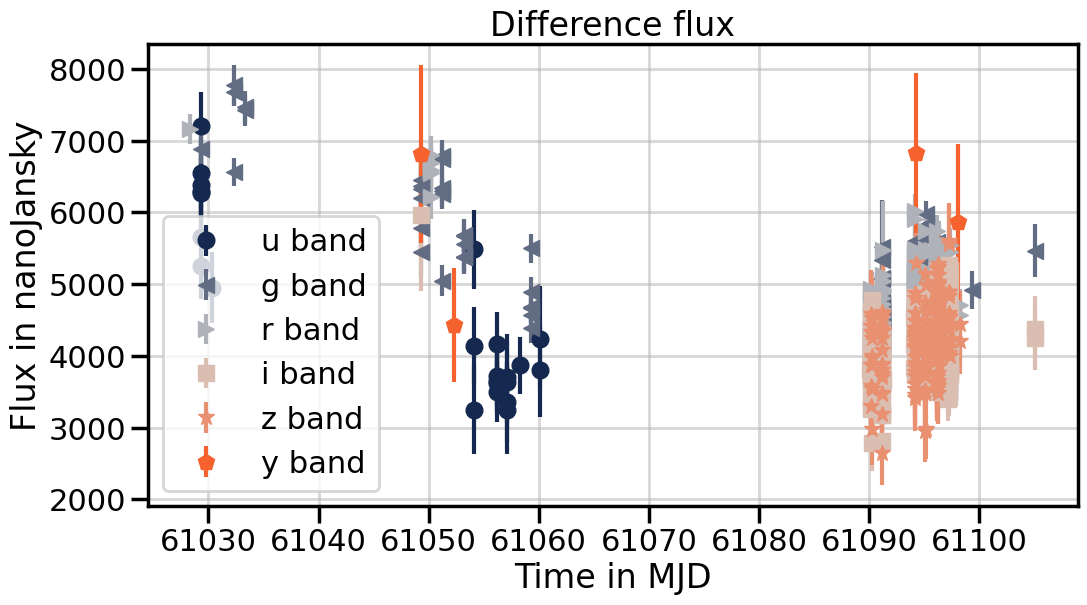

In [5]:
for _, alert in pdf.iterrows():
    mjd = extract_field(alert, "midpointMjdTai", current="diaSource", previous="prvDiaSources")
    psfFlux = extract_field(alert, "psfFlux", current="diaSource", previous="prvDiaSources")
    psfFluxErr = extract_field(alert, "psfFluxErr", current="diaSource", previous="prvDiaSources")
    band = extract_field(alert, "band", current="diaSource", previous="prvDiaSources")

    # mask NaN values
    mask = ~pd.isna(psfFluxErr)

    fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(12, 6))
    plot_lightcurve_allbands(
        mjd[mask], 
        psfFlux[mask], 
        psfFluxErr[mask], 
        band[mask], 
        ax=ax,
        label="Difference flux (r band)",
    )
    
    ax.grid(alpha=0.5)
    ax.legend()
    ax.set_ylabel("Flux in nanoJansky")
    ax.set_xlabel("Time in MJD")
    ax.set_title(f"Difference flux")
    plt.show()

You can substitute `psfFlux` with `scienceFlux` or `templateFlux` to get forced photometry on the science or template image based on `diaSource` positions:

## Forced photometry using diaObject positions

In addition, you can also access flux estimated using forced PSF photometry on the difference (or science) image, based on `diaObject` positions (not `diaSource`):

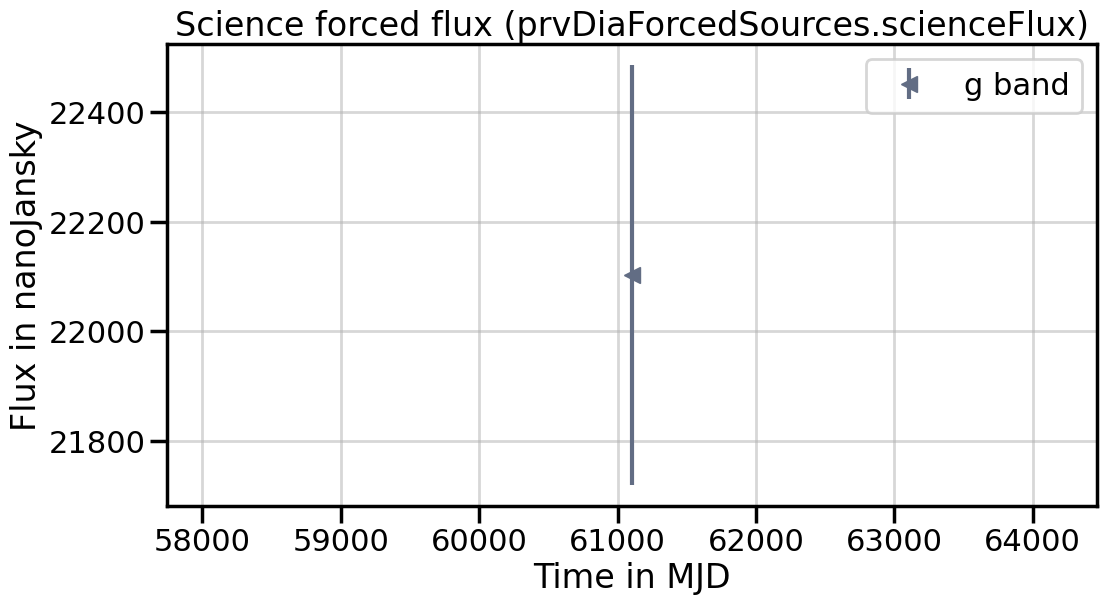

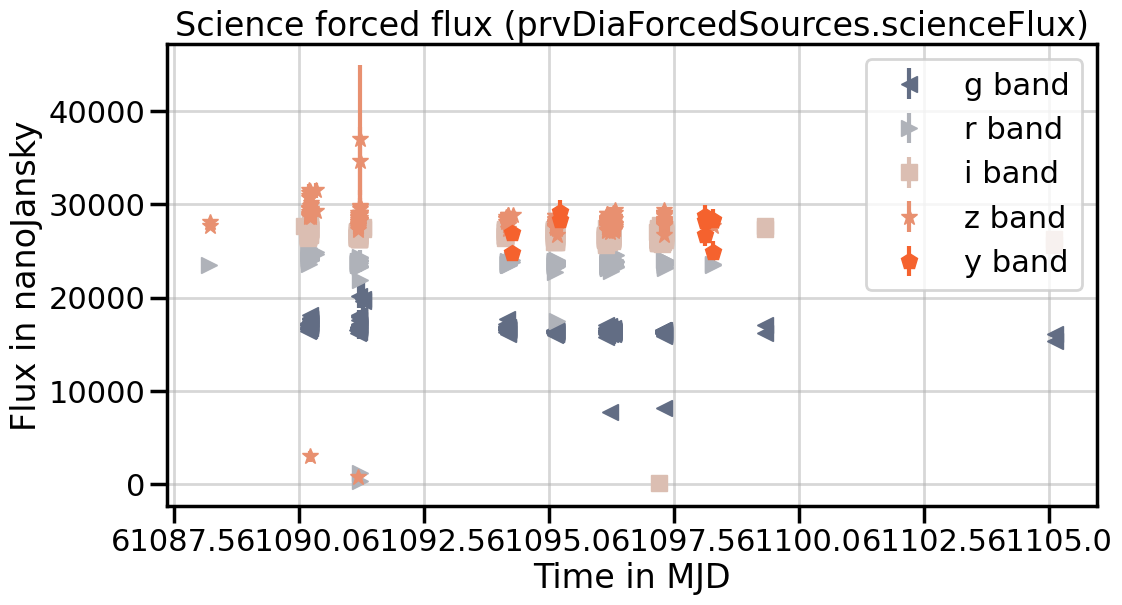

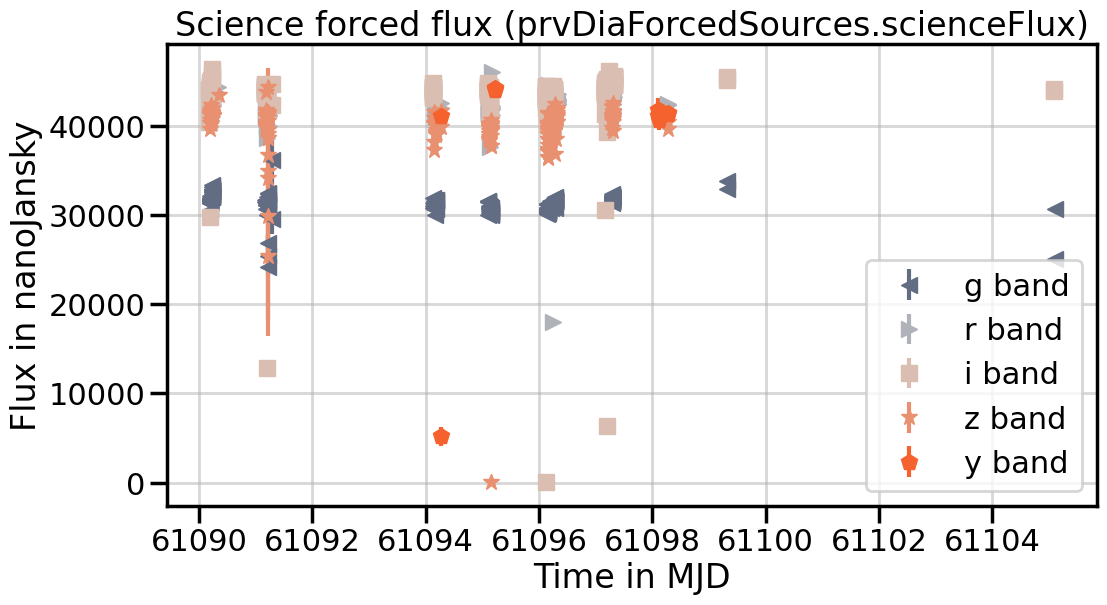

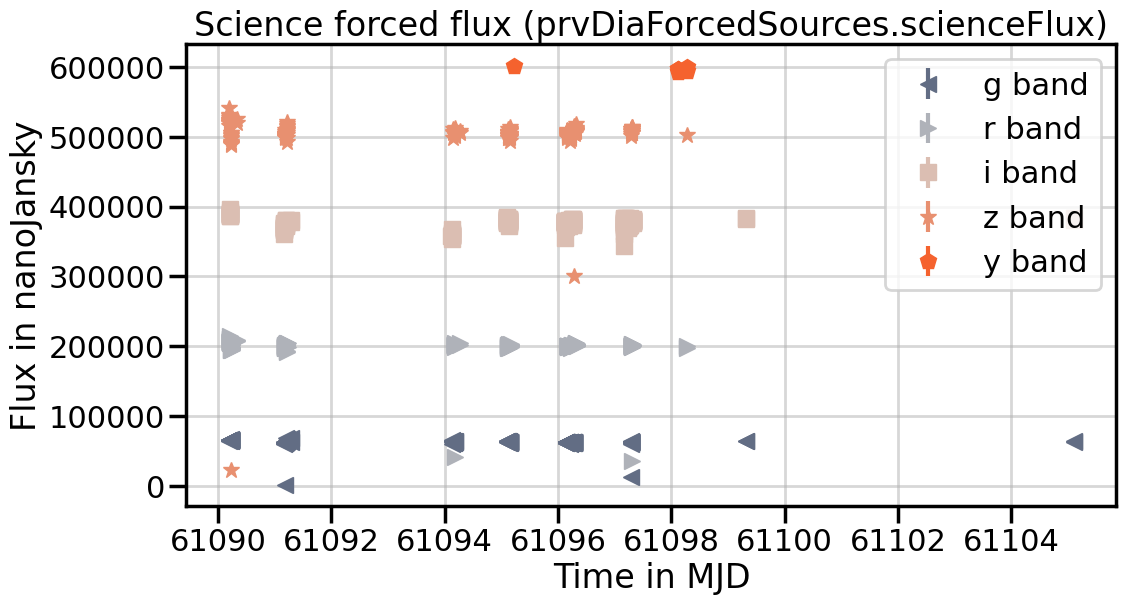

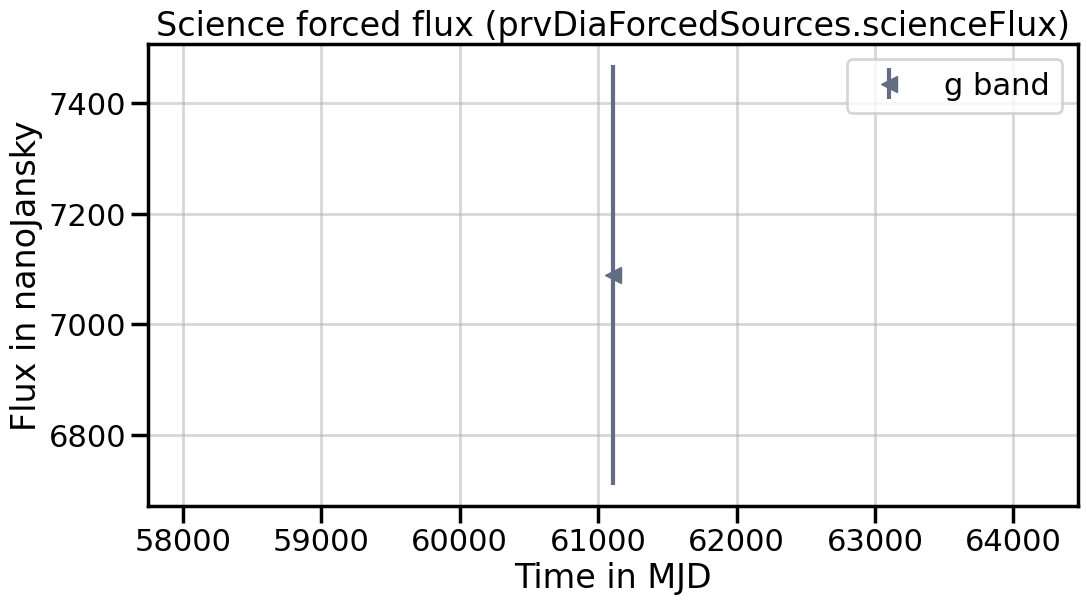

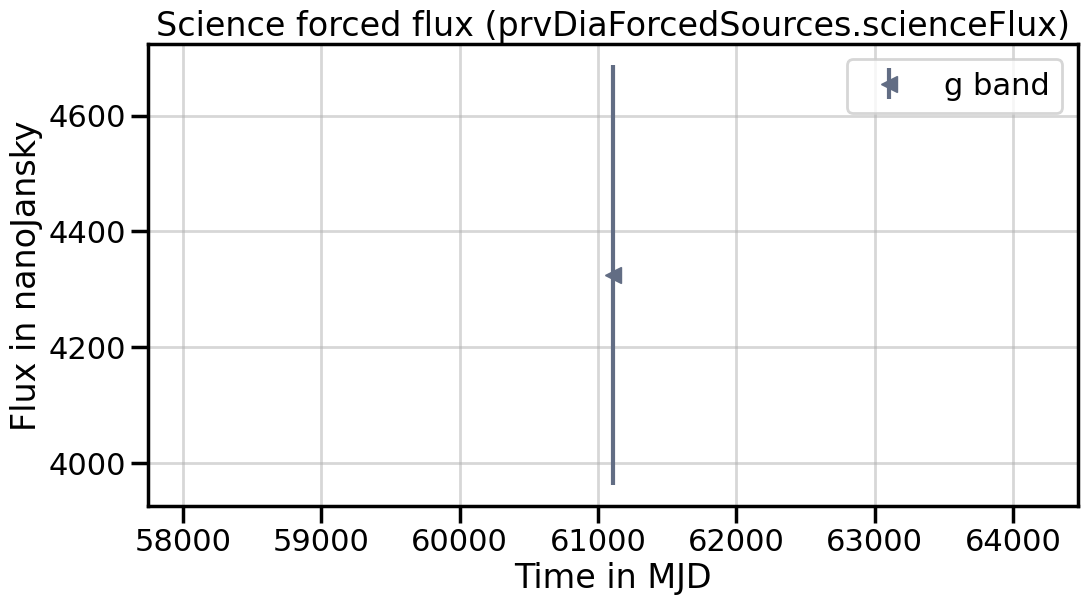

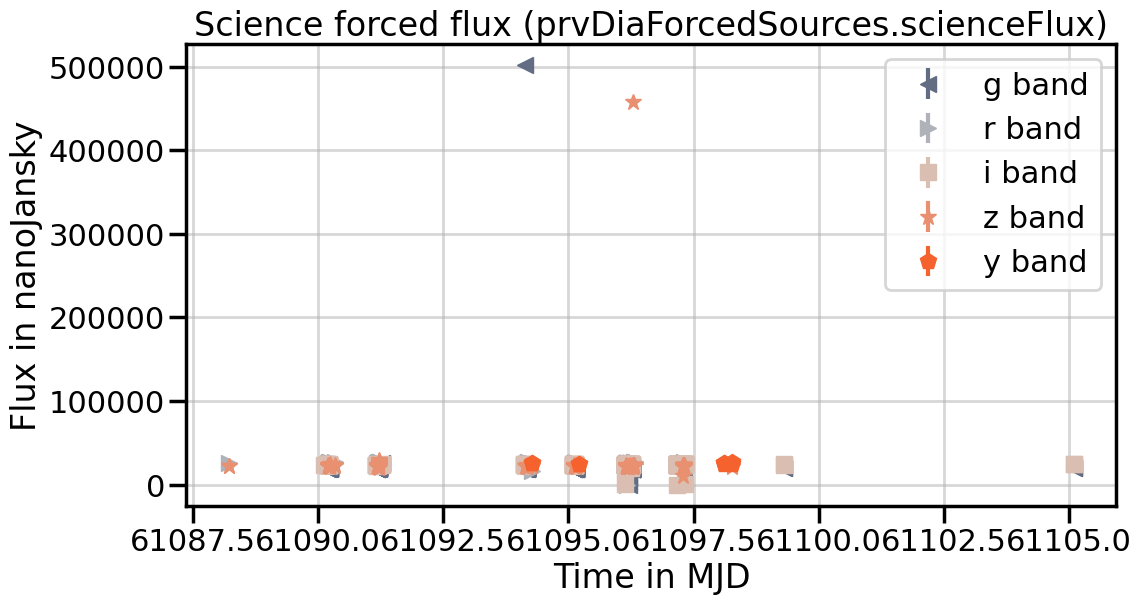

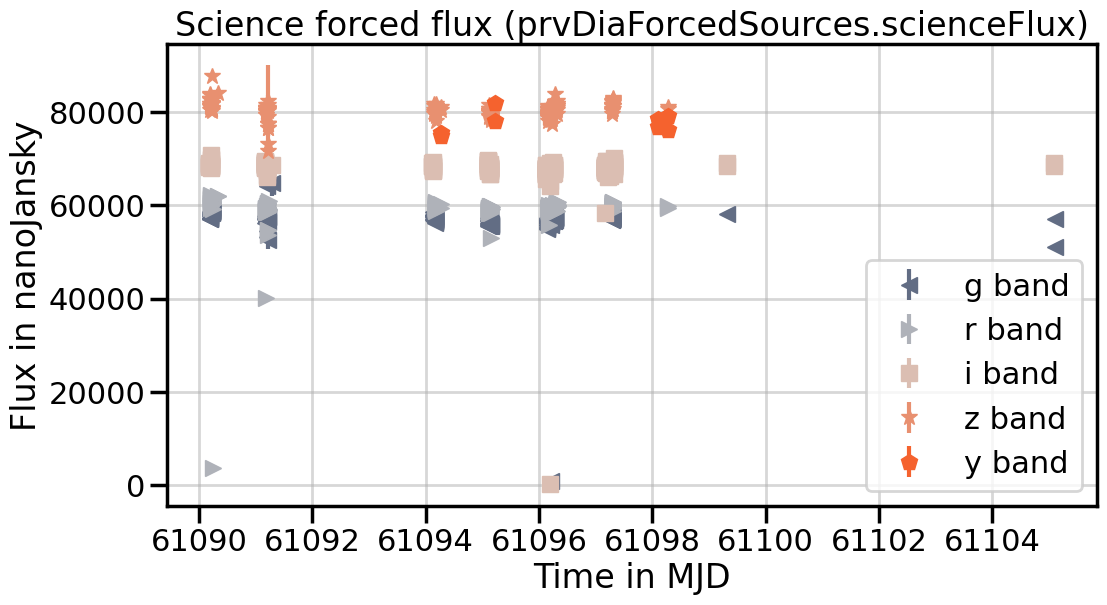

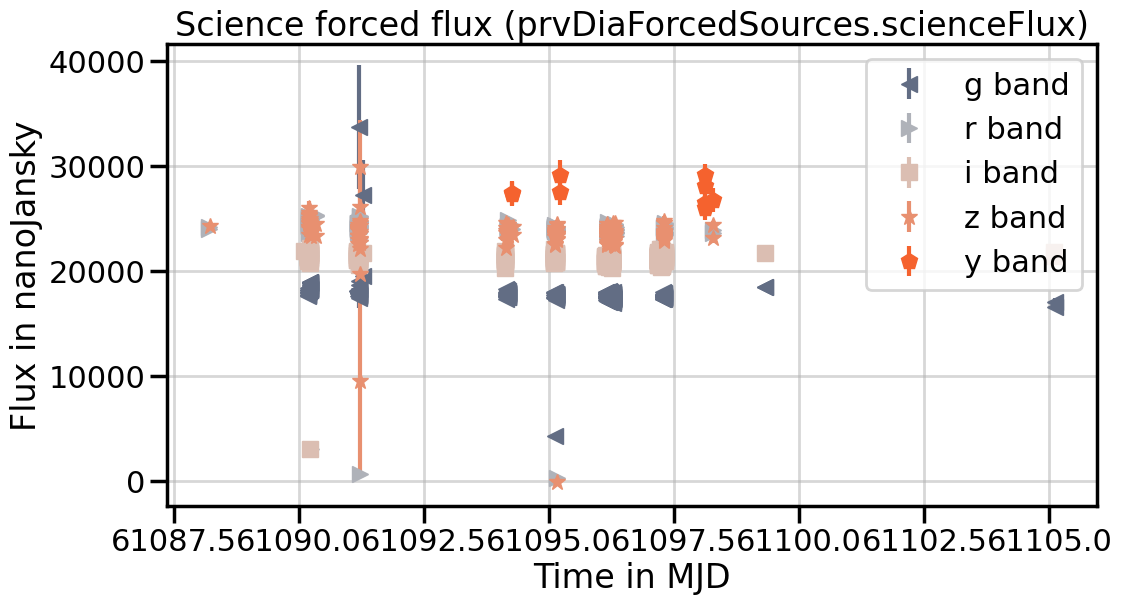

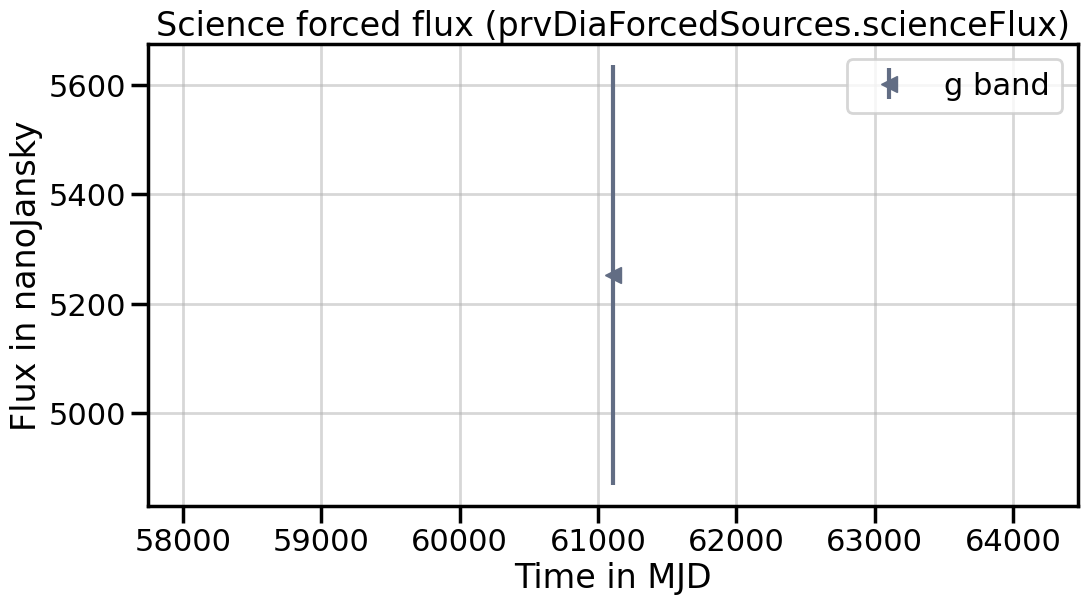

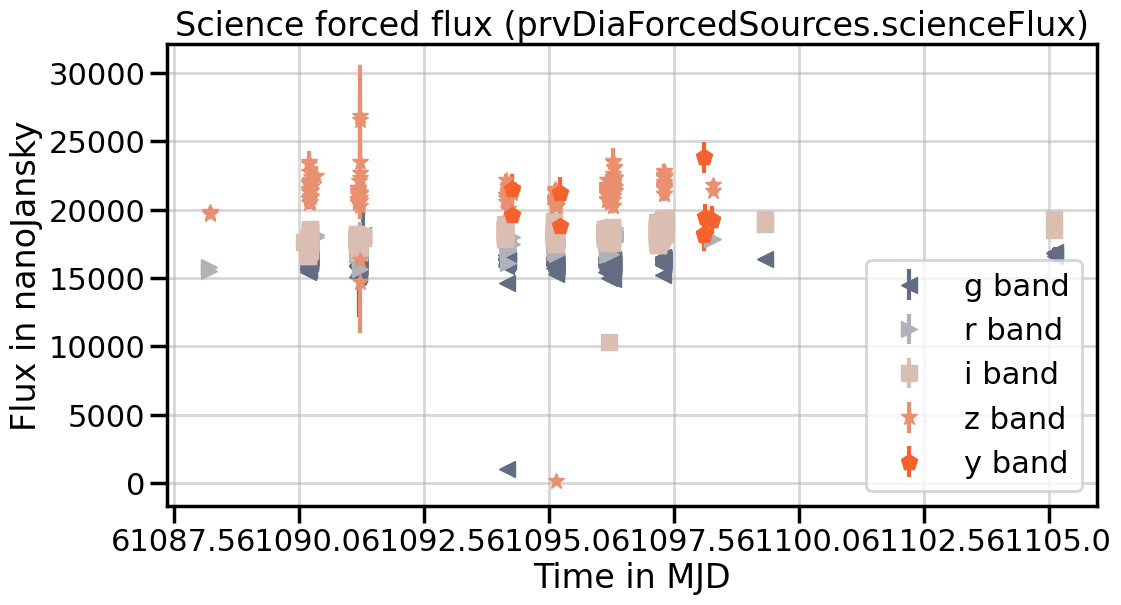

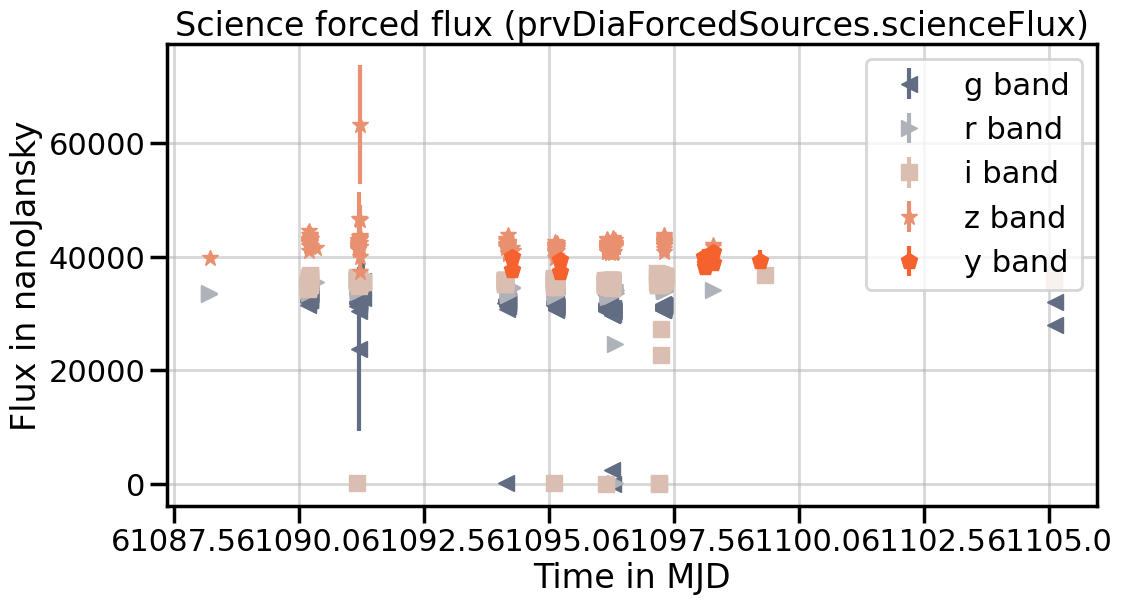

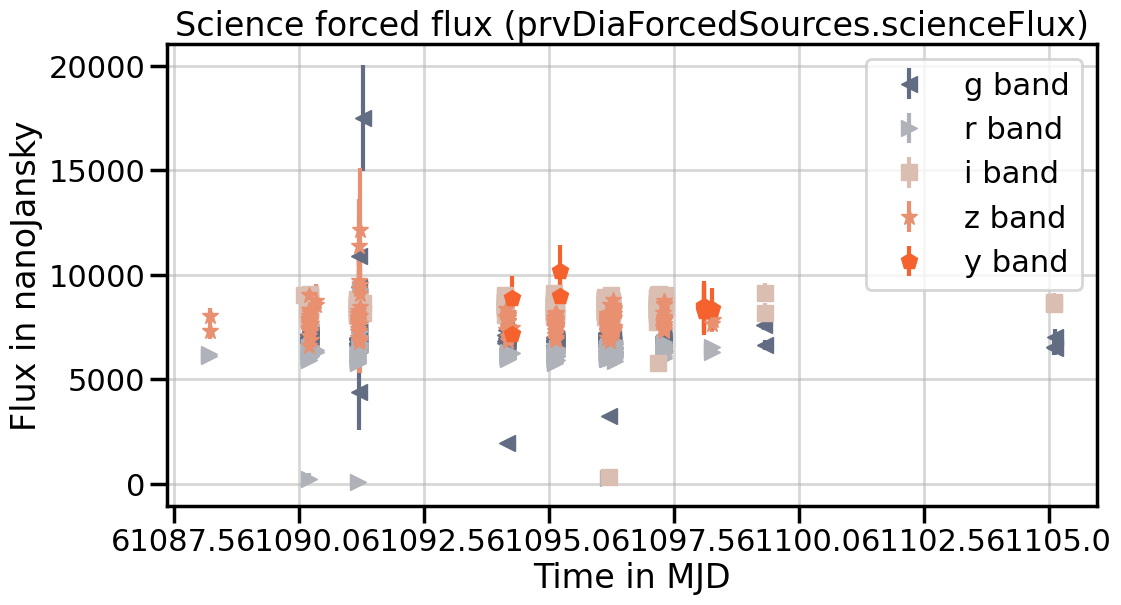

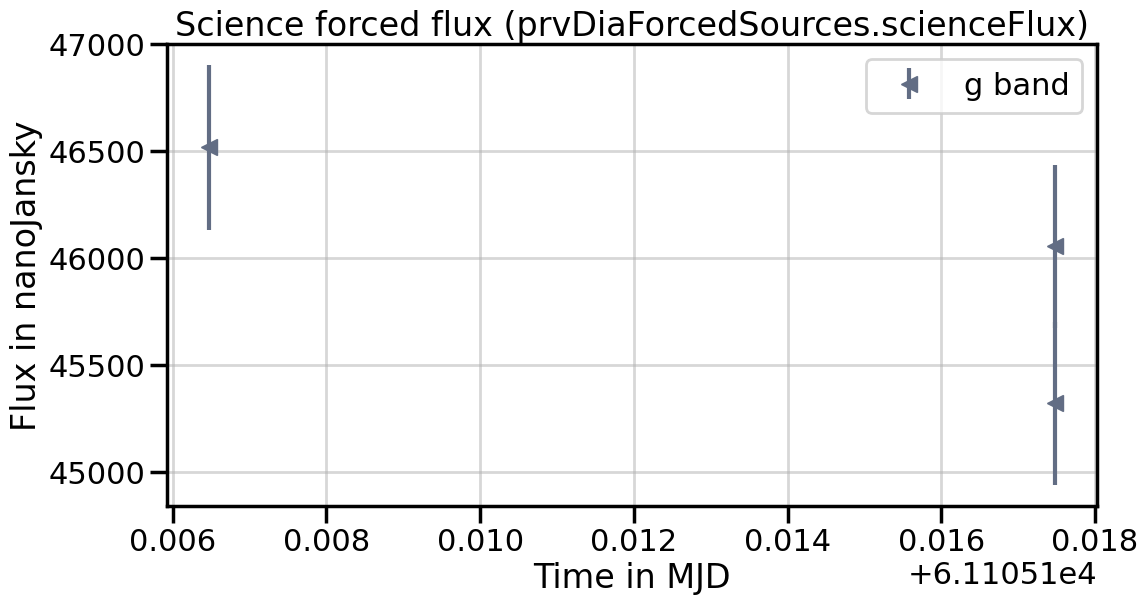

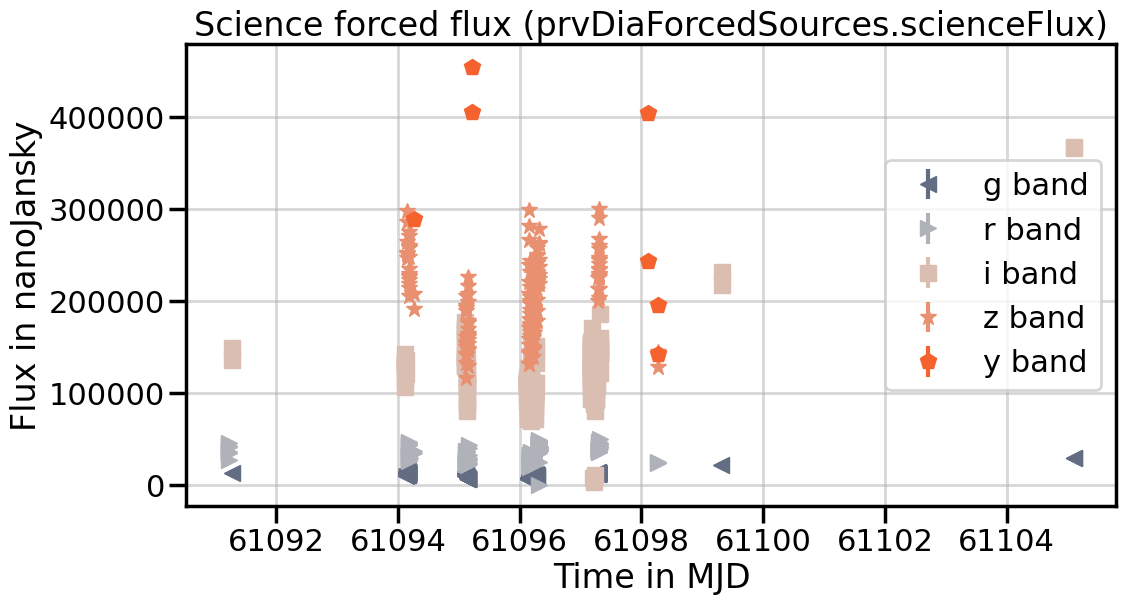

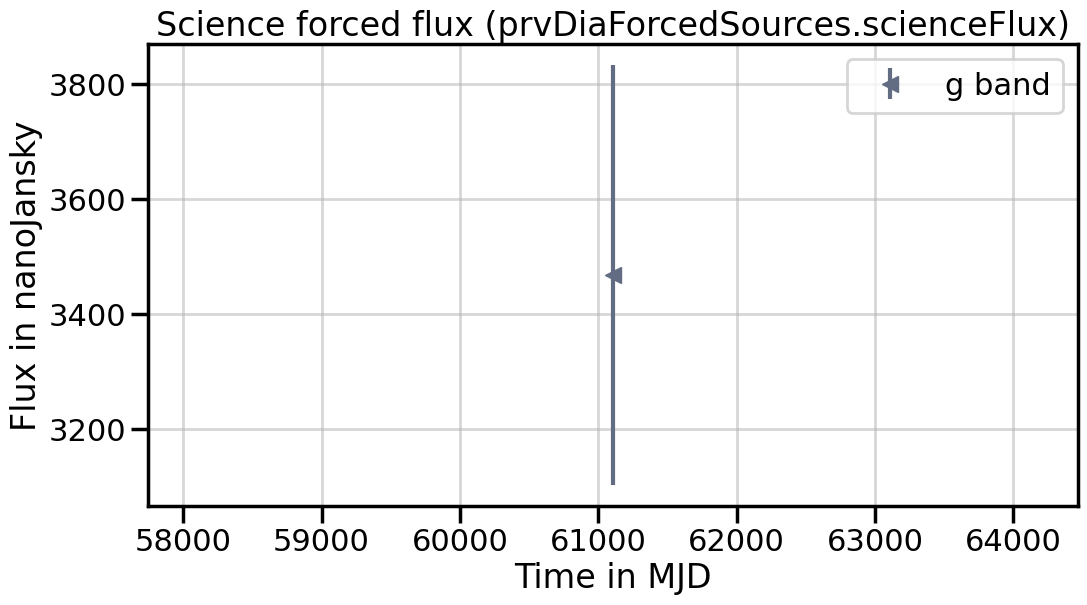

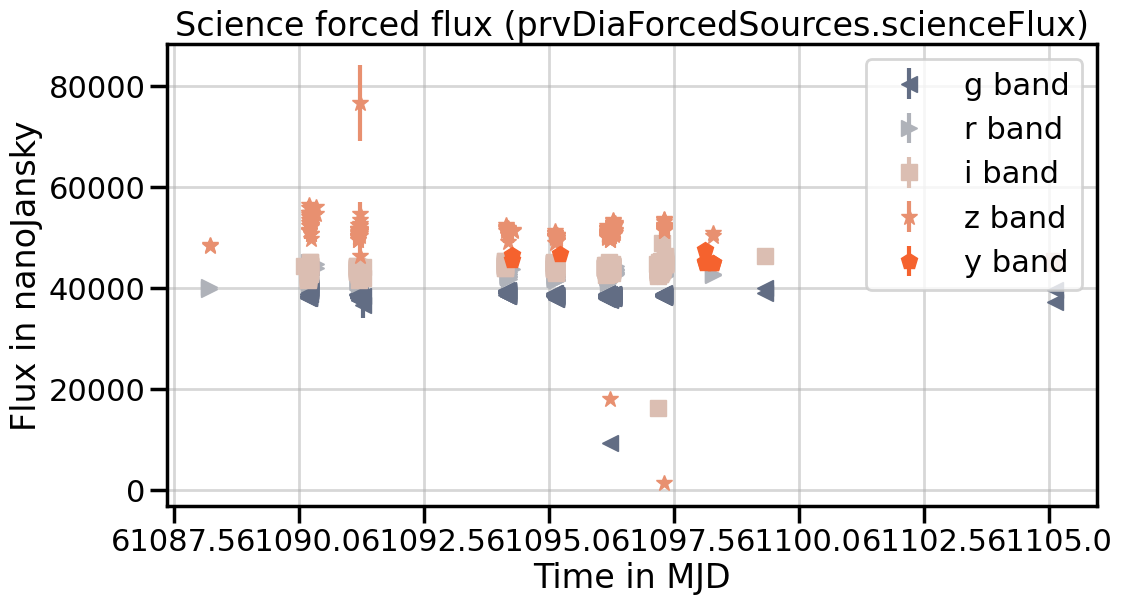

In [6]:
for _, alert in pdf.iterrows():
    mjd = extract_field(alert, "midpointMjdTai", current="diaSource", previous="prvDiaForcedSources")
    psfFlux = extract_field(alert, "scienceFlux", current="diaSource", previous="prvDiaForcedSources")
    psfFluxErr = extract_field(alert, "scienceFluxErr", current="diaSource", previous="prvDiaForcedSources")
    band = extract_field(alert, "band", current="diaSource", previous="prvDiaForcedSources")

    # mask NaN values
    mask = ~pd.isna(psfFluxErr)

    fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(12, 6))
    plot_lightcurve_allbands(
        mjd[mask], 
        psfFlux[mask], 
        psfFluxErr[mask], 
        band[mask], 
        ax=ax,
        label="Science flux (r band)",
    )
    
    ax.grid(alpha=0.5)
    ax.legend()
    ax.set_ylabel("Flux in nanoJansky")
    ax.set_xlabel("Time in MJD")
    ax.set_title(f"Science forced flux (prvDiaForcedSources.scienceFlux)")
    plt.show()